# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

* Running the code locally in an Anaconda environment with Jupyter Notebook, I have all the libraries I need

In [ ]:
# Installing the libraries with the specified version.
#!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [1]:
# import libraries for data manipulation
import numpy as np
import pandas as pd
from pathlib import Path

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [2]:
# uncomment and run the following lines for Google Colab
# from google.colab import drive
# drive.mount('/content/drive')
path_to_foodhub_data = Path('data', 'foodhub_order.csv')

#### Using pathlib to specify path to the dataset.

In [3]:
# Write your code here to read the data
df_foodhub_orders = pd.read_csv(path_to_foodhub_data)

In [4]:
# Write your code here to view the first 5 rows
df_foodhub_orders.head(5)

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [5]:
# Write your code here
print(f'Shape of the Foodhub orders dataframe is: {df_foodhub_orders.shape}')

Shape of the Foodhub orders dataframe is: (1898, 9)


#### Observations:
* The dataframe or dataset has 1898 rows and 9 columns

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [6]:
# Write your code here
df_foodhub_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:

* int64 data type columns are order_id, customer_id, food_preparation_time, and delivery_time
* float64 data type columns are cost_of_the_order
* object/string data type (may have to change data types later from data exploration) are restaurant_name, cuisine_type, day_of_the_week, and rating
* rating is out of 5 as mentioned in the description above. It might have to be changed to int or float based on data exploration below

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [7]:
# Write your code here
df_foodhub_orders.isna().sum()

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

In [8]:
for column_name in df_foodhub_orders.columns:
    print('###################################')
    print(f'Value counts or freqencies for {column_name}')
    print(df_foodhub_orders[column_name].value_counts())
    print('###################################')

###################################
Value counts or freqencies for order_id
order_id
1478056    1
1477147    1
1477685    1
1477070    1
1477334    1
          ..
1477449    1
1478198    1
1477414    1
1477486    1
1477373    1
Name: count, Length: 1898, dtype: int64
###################################
###################################
Value counts or freqencies for customer_id
customer_id
52832     13
47440     10
83287      9
250494     8
65009      7
          ..
135970     1
102010     1
363202     1
101957     1
145216     1
Name: count, Length: 1200, dtype: int64
###################################
###################################
Value counts or freqencies for restaurant_name
restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
                            ... 
Rye House                      1
Hiroko's Place                 1
Frank Restaurant       

#### Observations:

* There are no nan or null values from isna().sum() of all columns

* Value_counts() for each column is all clean, except for rating which has 'Not Given' as an option and rest of the values are numeric.

* Rating is a number out of 5 and looks like value counts are Not Given, 3, 4, 5. I have replaced Not Given with np.nan and converted the Rating column dtype to float64. If I use int or int64 getting error np.nan can't be converted to int. Also, rating was not showing up in the describe or statistical summary. Code for that is below this cell.

* Switching rating from object to numeric will benefit us in doing numerical calculations and in statistical summary table later.


In [9]:
df_foodhub_orders['rating'] = df_foodhub_orders['rating'].replace('Not given', np.nan)
df_foodhub_orders['rating']= df_foodhub_orders['rating'].astype(np.float64)
df_foodhub_orders['rating'].value_counts()

rating
5.0    588
4.0    386
3.0    188
Name: count, dtype: int64

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [10]:
# Write your code here
df_foodhub_orders.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
rating,1162.0,4.344234e+00,0.741478,3.00,4.00,5.00,5.000000e+00,5.00
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


#### Observations:
* Minimum food preparation time is : 20 minutes
* Average food preparation time is: 27.37 minutes
* Maximum food preparation time is: 35 minutes

### **Question 5:** How many orders are not rated? [1 mark]

In [11]:
# Write the code here
df_foodhub_orders['rating'].isna().sum()

np.int64(736)

#### Observations:
* 736 orders or rows of column rating are np.nan rating or 'Not Given' which we replaced with np.nan earlier.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

In [12]:
# Write the code here
# Generating all the column names first
df_foodhub_orders.columns

Index(['order_id', 'customer_id', 'restaurant_name', 'cuisine_type',
       'cost_of_the_order', 'day_of_the_week', 'rating',
       'food_preparation_time', 'delivery_time'],
      dtype='object')

In [13]:
# order_id looks like a unique identifier for each order
# Length of order_id value counts matches the rows of the dataframe
df_foodhub_orders['order_id'].value_counts()

order_id
1478056    1
1477147    1
1477685    1
1477070    1
1477334    1
          ..
1477449    1
1478198    1
1477414    1
1477486    1
1477373    1
Name: count, Length: 1898, dtype: int64

In [14]:
# Customer identifies is unique identification for each customer
# Value_counts shows us the most frequent customers
# 1200 unique customer_ids
df_foodhub_orders['customer_id'].value_counts()

customer_id
52832     13
47440     10
83287      9
250494     8
65009      7
          ..
135970     1
102010     1
363202     1
101957     1
145216     1
Name: count, Length: 1200, dtype: int64

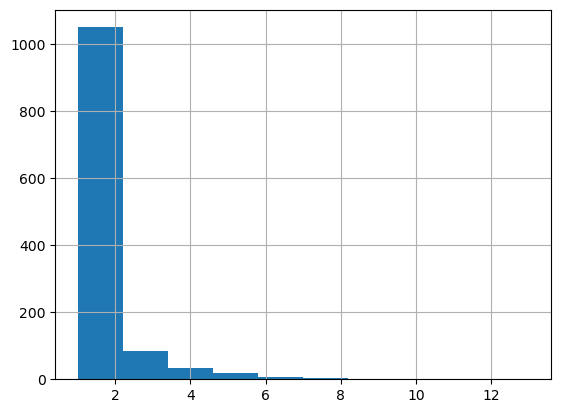

In [15]:
# Deterimine most frequent customers who order food
df_foodhub_orders['customer_id'].value_counts().hist();

In [16]:
# 178 unique restaurants in the dataframe
# Most popular are Shake Shack, The Meatball Shop and Blue Ribbon Sushi
df_foodhub_orders['restaurant_name'].value_counts()

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
                            ... 
Rye House                      1
Hiroko's Place                 1
Frank Restaurant               1
Sarabeth's West                1
'wichcraft                     1
Name: count, Length: 178, dtype: int64

In [17]:
# 178 unique restaurants in the dataframe
df_foodhub_orders['restaurant_name'].value_counts(normalize=True)

restaurant_name
Shake Shack                  0.115385
The Meatball Shop            0.069547
Blue Ribbon Sushi            0.062698
Blue Ribbon Fried Chicken    0.050580
Parm                         0.035827
                               ...   
Rye House                    0.000527
Hiroko's Place               0.000527
Frank Restaurant             0.000527
Sarabeth's West              0.000527
'wichcraft                   0.000527
Name: proportion, Length: 178, dtype: float64

In [18]:
# Top 5 restaurants account for 33.4% of the orders or close to 1 out of every 3 orders
df_foodhub_orders['restaurant_name'].value_counts(normalize=True).iloc[:5].sum()

np.float64(0.33403582718651215)

In [19]:
df_foodhub_orders['cuisine_type'].value_counts()

cuisine_type
American          584
Japanese          470
Italian           298
Chinese           215
Mexican            77
Indian             73
Middle Eastern     49
Mediterranean      46
Thai               19
French             18
Southern           17
Korean             13
Spanish            12
Vietnamese          7
Name: count, dtype: int64

In [20]:
len(df_foodhub_orders['cuisine_type'].value_counts())

14

In [21]:
df_foodhub_orders['cuisine_type'].value_counts(normalize=True)

cuisine_type
American          0.307692
Japanese          0.247629
Italian           0.157007
Chinese           0.113277
Mexican           0.040569
Indian            0.038462
Middle Eastern    0.025817
Mediterranean     0.024236
Thai              0.010011
French            0.009484
Southern          0.008957
Korean            0.006849
Spanish           0.006322
Vietnamese        0.003688
Name: proportion, dtype: float64

In [22]:
df_foodhub_orders['cuisine_type'].value_counts(normalize=True).iloc[:5].sum()

np.float64(0.8661749209694415)

#### Observations for cuisine_type

* 14 Unique cuisine types
* Most popular American accounting for 30.77% of the orders, with Vietnamese being least popular with 0.37% of the orders
* Top 5 cuisines account for 86.62% of the orders and them being American, Japanese, Italian, Chinese, and Mexican

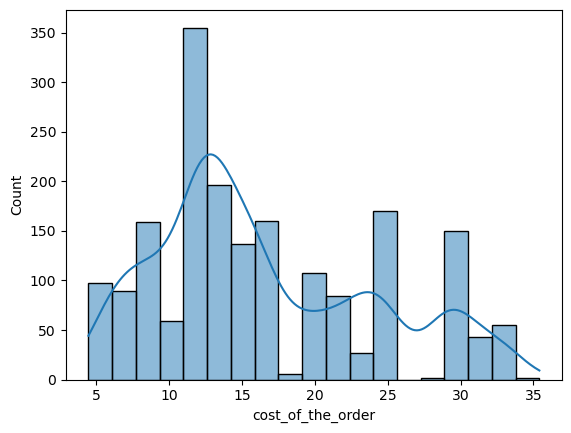

In [23]:
# right skewed distribution
sns.histplot(data=df_foodhub_orders, x="cost_of_the_order", kde=True);

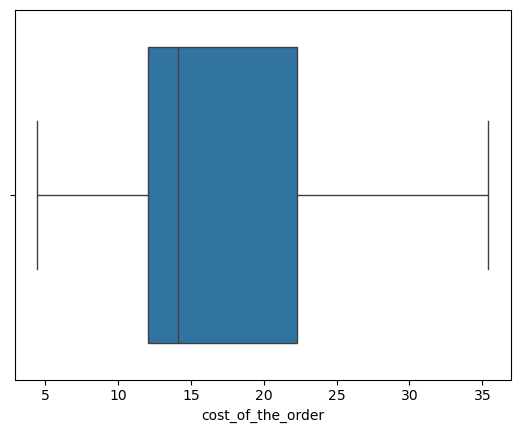

In [24]:
# No outliers present for cost of the order
sns.boxplot(data=df_foodhub_orders, x="cost_of_the_order");

In [25]:
df_foodhub_orders.cost_of_the_order.describe().T

count    1898.000000
mean       16.498851
std         7.483812
min         4.470000
25%        12.080000
50%        14.140000
75%        22.297500
max        35.410000
Name: cost_of_the_order, dtype: float64

#### Observations

* Cost of the order is a right skewed distribution with no outliers observed in the box plot
* Mean order cost is 16.5 with minimum of 4.47 and maximum of 35.41. All in dollars.

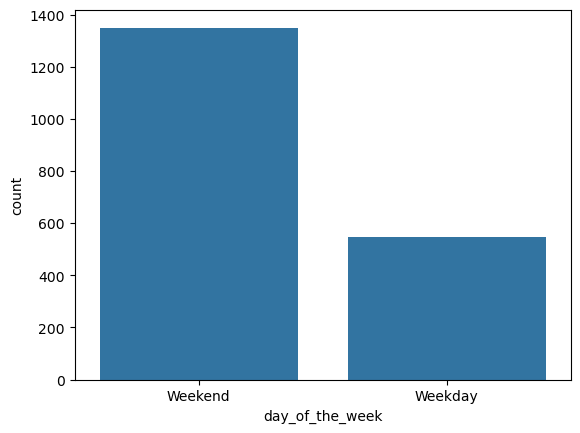

In [26]:
sns.countplot(df_foodhub_orders, x="day_of_the_week");

####
* More orders on the weekend than weekdays, eventhough weekends constitute 2/7 days in the week.

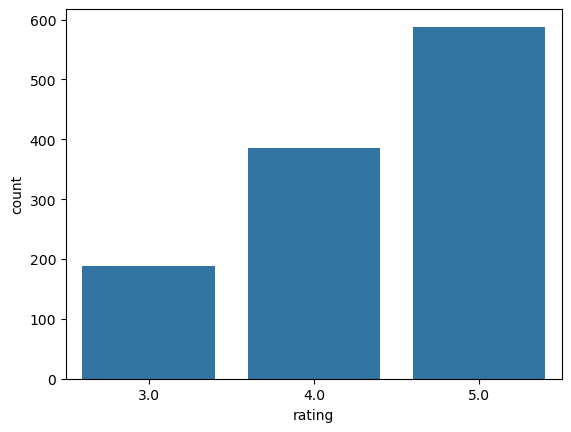

In [27]:
sns.countplot(df_foodhub_orders, x="rating");

#### Observations
* Restaurant rating counts are skewed towards higher rating of 5.0
* The restaurants within the Foodhub system are highly rated.

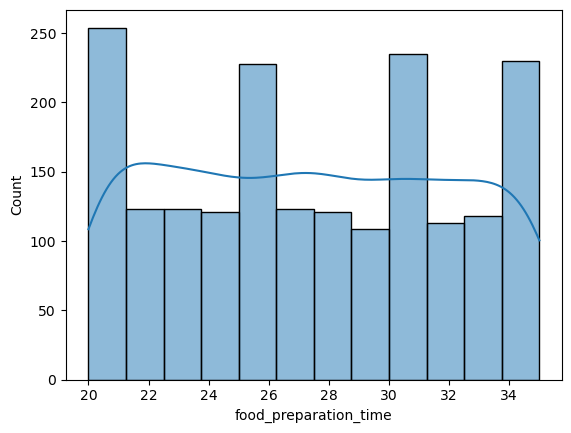

In [28]:
sns.histplot(df_foodhub_orders, x="food_preparation_time", kde=True);

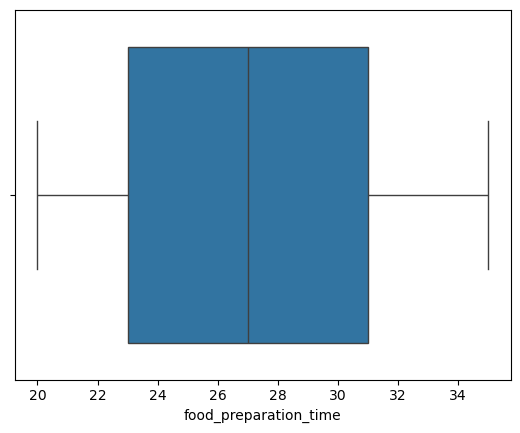

In [29]:
sns.boxplot(df_foodhub_orders, x="food_preparation_time");

#### Observations
* Food preparation time seems to have spikes at 20, 25, 30, and 35 minutes and overall seems uniform distribution.
* No outliers detected in the boxplot for food preparation time

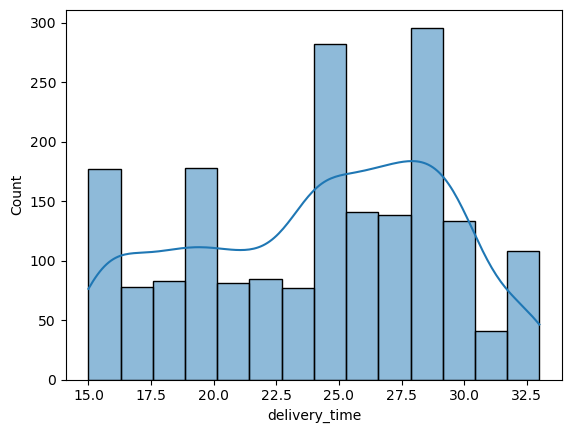

In [30]:
sns.histplot(df_foodhub_orders, x="delivery_time", kde=True);

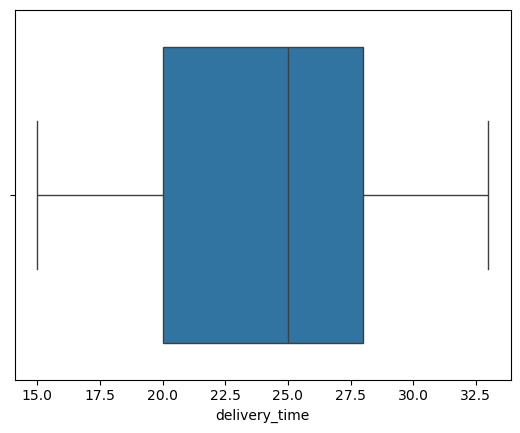

In [31]:
sns.boxplot(df_foodhub_orders, x="delivery_time");

In [32]:
df_foodhub_orders.delivery_time.describe().T

count    1898.000000
mean       24.161749
std         4.972637
min        15.000000
25%        20.000000
50%        25.000000
75%        28.000000
max        33.000000
Name: delivery_time, dtype: float64

#### Observations
* Delivery time is righ skewed distibution with no outliers detected in boxplot.
* Average delivery time is 24.2 minutes, with minimum at 15 minutes and maximum at 33 minutes.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [33]:
# Write the code here
df_foodhub_orders['restaurant_name'].value_counts()[:5]

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64

#### Observations:
* From value_counts() on restaurant name we see the top 5 restaurants are Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken, and Parm

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [34]:
# Write the code here
df_foodhub_orders[df_foodhub_orders['day_of_the_week']=='Weekend']['cuisine_type'].value_counts()

cuisine_type
American          415
Japanese          335
Italian           207
Chinese           163
Mexican            53
Indian             49
Middle Eastern     32
Mediterranean      32
Thai               15
French             13
Korean             11
Southern           11
Spanish            11
Vietnamese          4
Name: count, dtype: int64

#### Observations:
* American
* By filtering day of the week to the weekend and applying value_counts() to the cuisine_type we see the most popular cuisine is:
  American

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [35]:
len(df_foodhub_orders)

1898

In [36]:
# Write the code here
100*len(df_foodhub_orders[df_foodhub_orders['cost_of_the_order']>20.0])/len(df_foodhub_orders)

29.24130663856691

#### Observations:

* Assuming cost_of_the_order column is in dollars, we have 29.24% of the orders greater than $20


### **Question 10**: What is the mean order delivery time? [1 mark]

In [37]:
# Write the code here
round(df_foodhub_orders.delivery_time.mean(), 3)

np.float64(24.162)

#### Observations:

* The mean value of delivery time is 24.162 minutes


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [38]:
df_foodhub_orders['customer_id'].value_counts()

customer_id
52832     13
47440     10
83287      9
250494     8
65009      7
          ..
135970     1
102010     1
363202     1
101957     1
145216     1
Name: count, Length: 1200, dtype: int64

In [39]:
# Write the code here
df_foodhub_orders['customer_id'].value_counts()[:3]

customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64

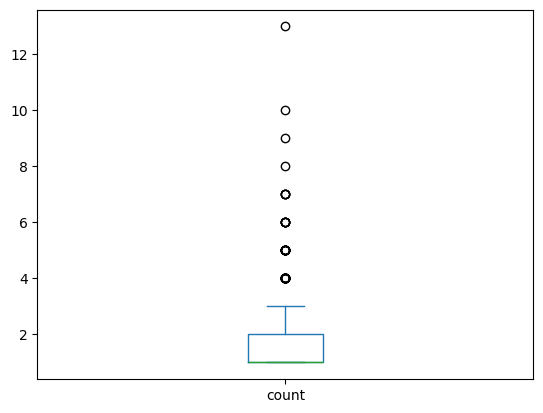

In [40]:
df_foodhub_orders['customer_id'].value_counts().plot.box();

#### Observations:
* The top three customers are 52832 with 13 orders, 47440 with 10 orders, and 83287 with 9 orders
* They are outliers as seen by plot of the boxplot of value_counts for customer_id values

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


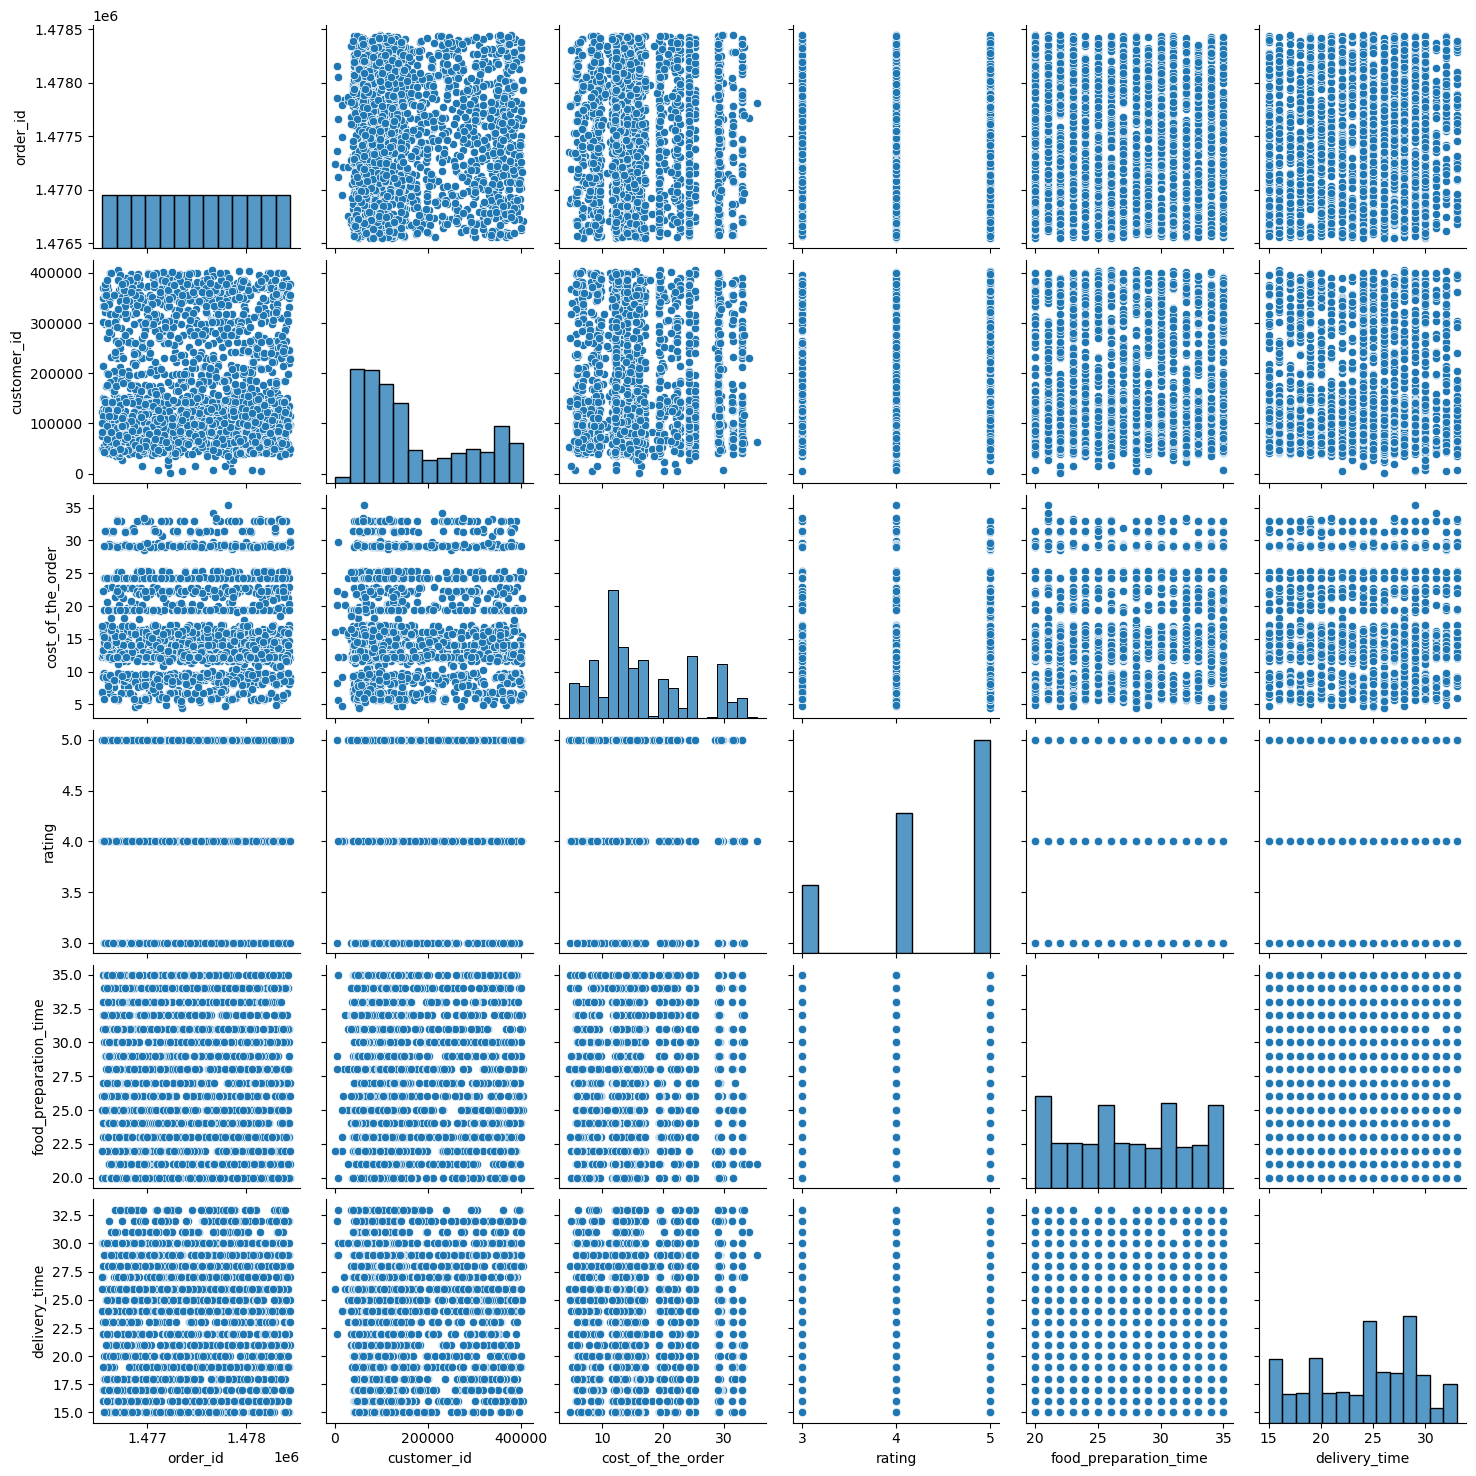

In [41]:
# Write the code here
sns.pairplot(df_foodhub_orders);

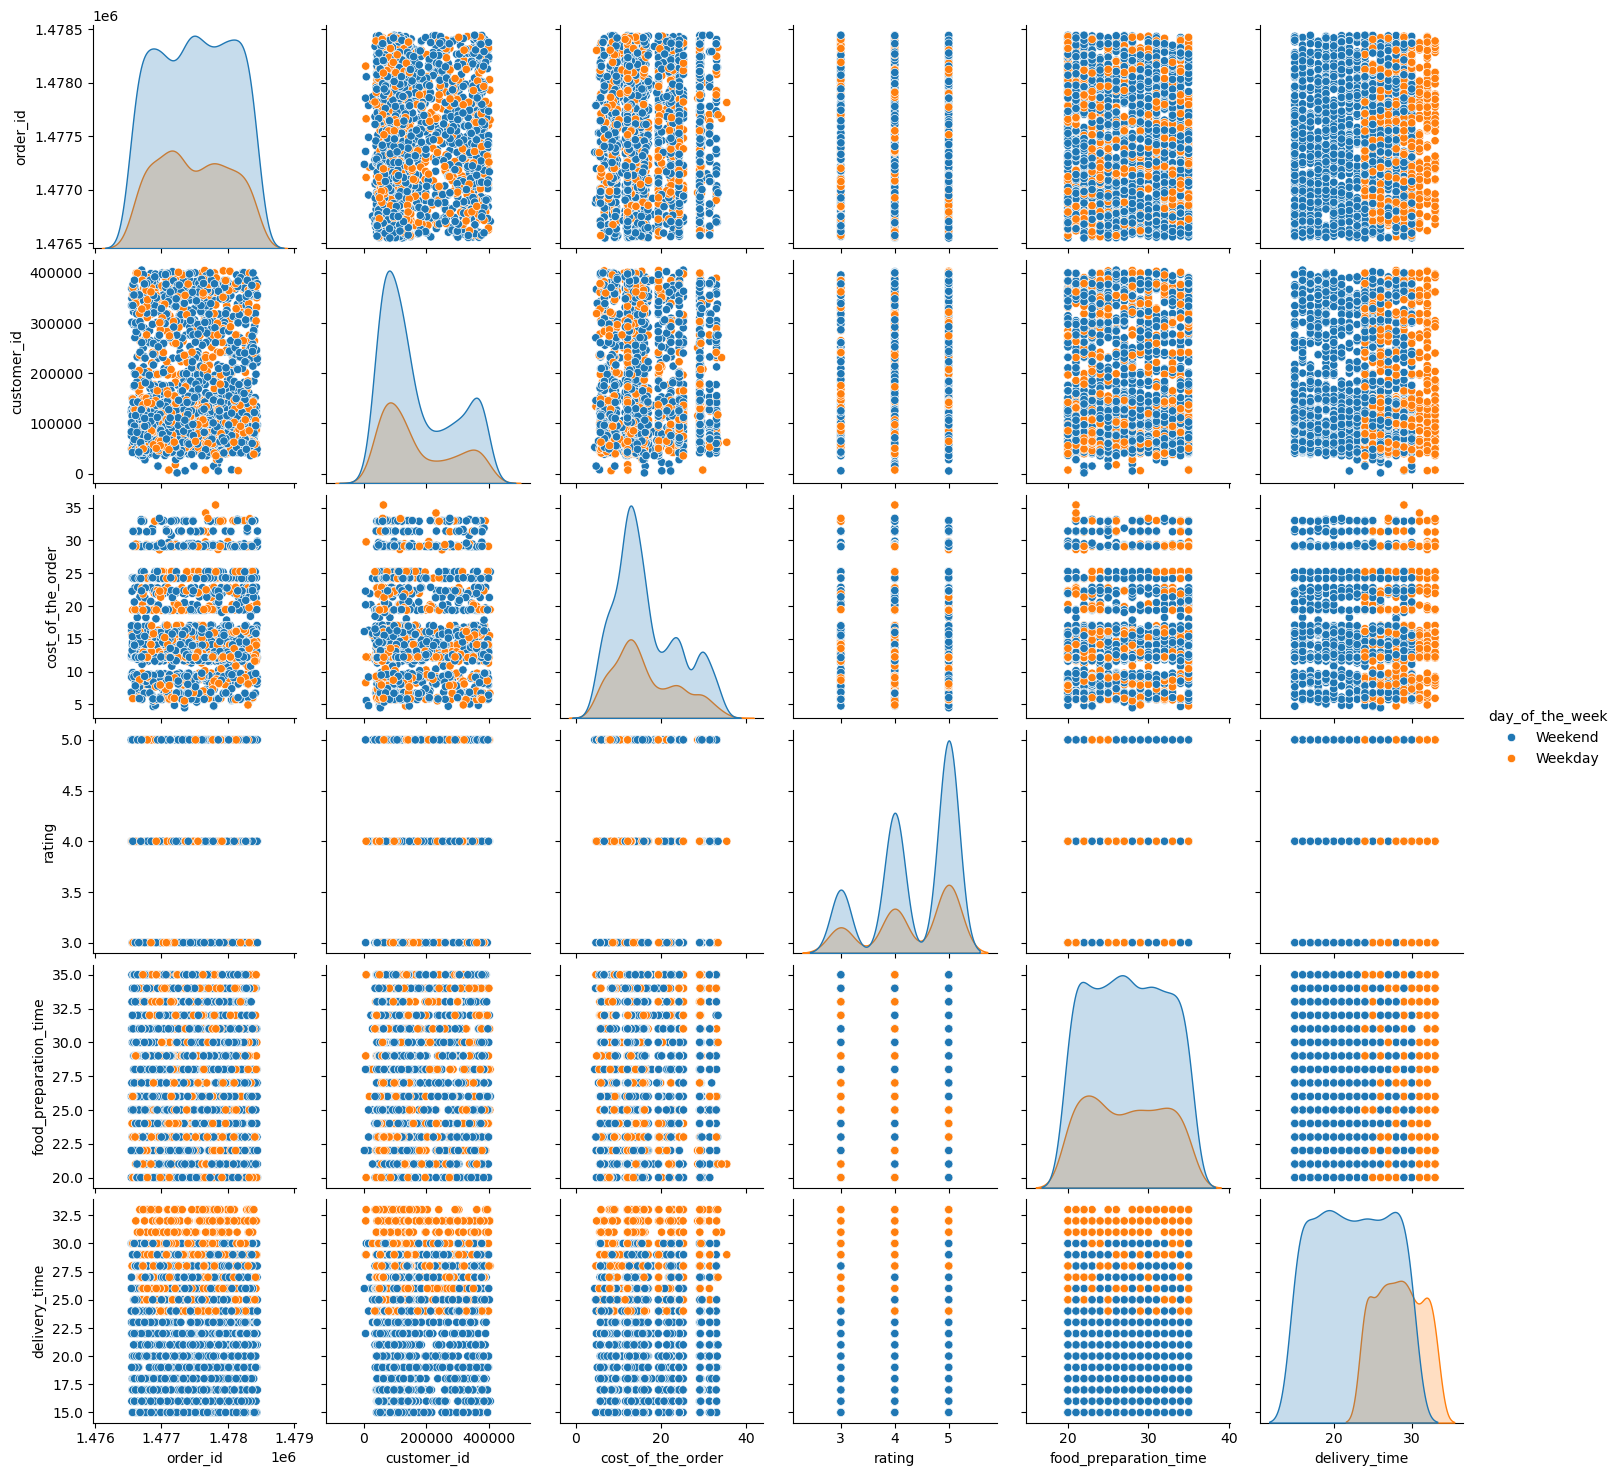

In [42]:
sns.pairplot(df_foodhub_orders, hue='day_of_the_week');

#### Observations
* Rating and delivery time are related to day_of_the_week or have some relationship with Weekends or Weekdays.

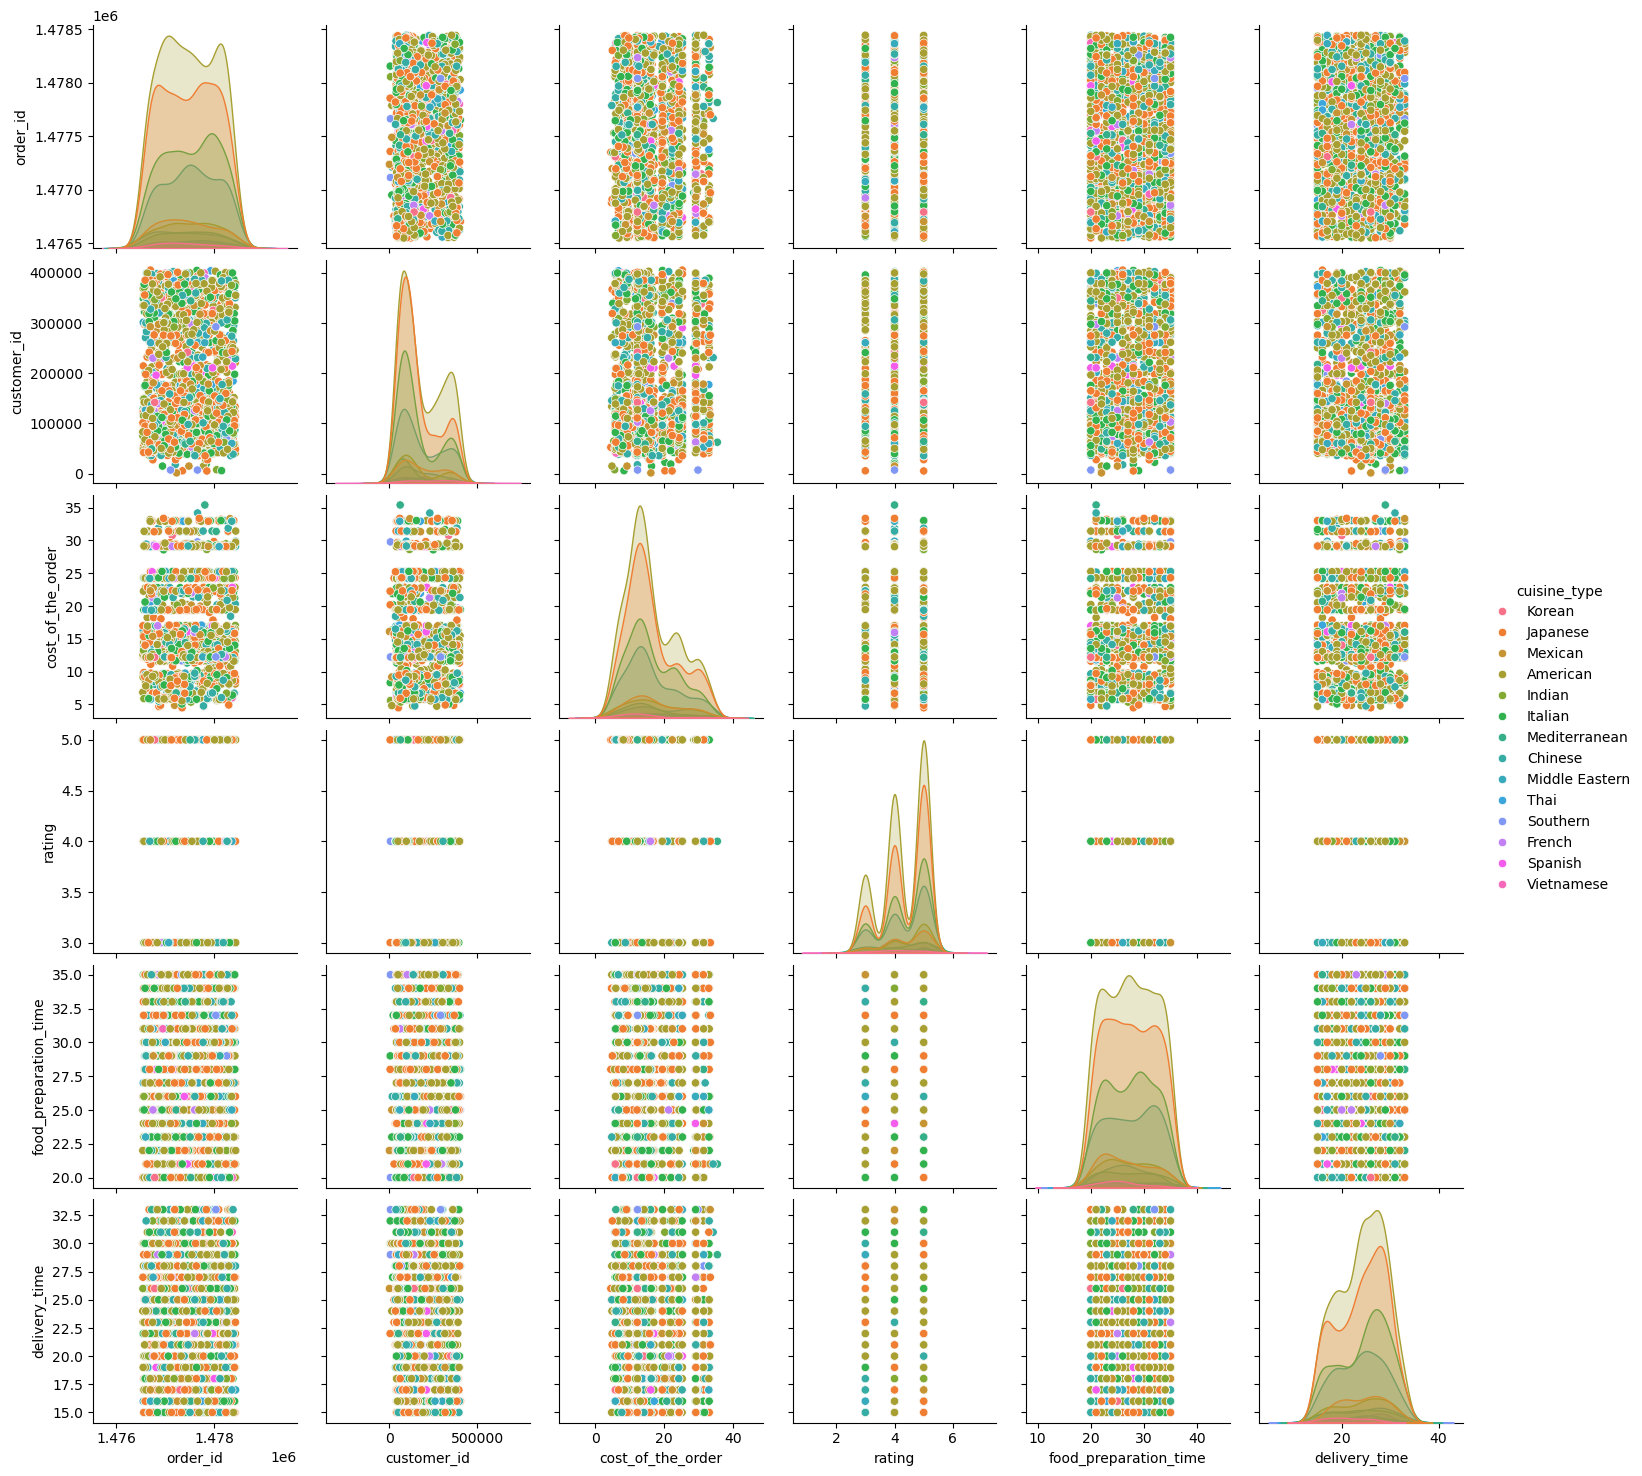

In [43]:
sns.pairplot(df_foodhub_orders, hue='cuisine_type');

#### Observations
* Some of the cuisines show dependency on ratings and delivery time, food_preparation_time

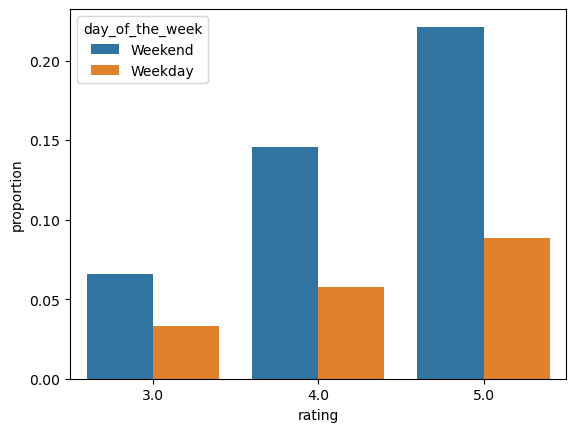

In [44]:
sns.countplot(df_foodhub_orders, x='rating', hue='day_of_the_week', stat='proportion');

#### Observations
* Weekend orders are more highly rated than weekday orders

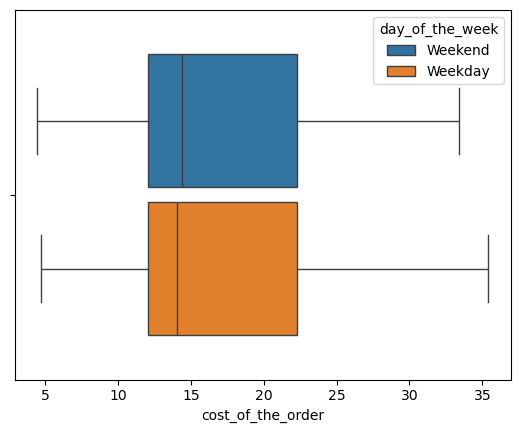

In [45]:
sns.boxplot(df_foodhub_orders, x='cost_of_the_order', hue='day_of_the_week', gap=0.1);

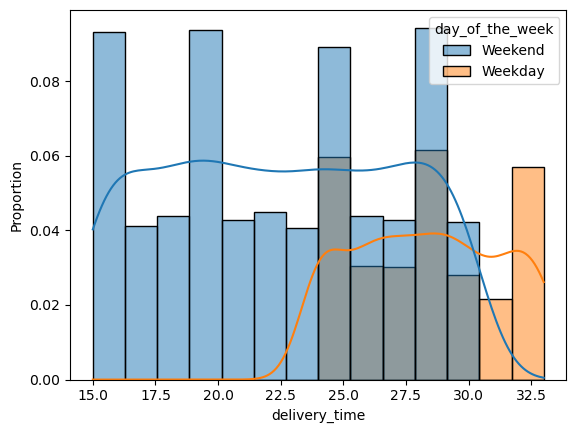

In [46]:
sns.histplot(df_foodhub_orders, x='delivery_time', hue='day_of_the_week', stat='proportion', kde=True);

<Axes: xlabel='delivery_time'>

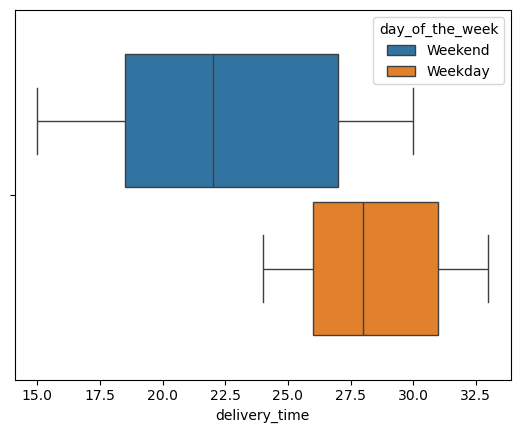

In [47]:
sns.boxplot(df_foodhub_orders, x='delivery_time', hue='day_of_the_week', gap=0.1)

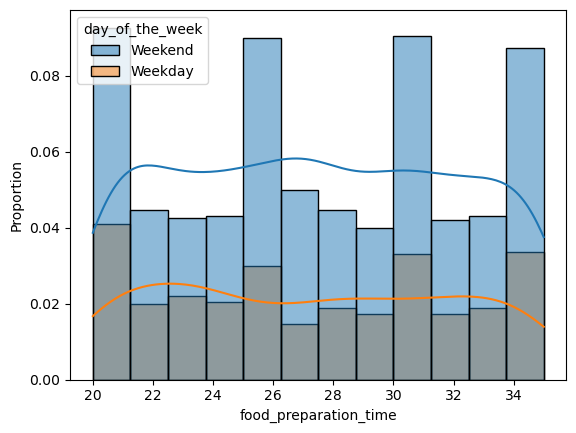

In [48]:
sns.histplot(df_foodhub_orders, x='food_preparation_time', hue='day_of_the_week', stat='proportion', kde=True);

#### Observations
* Weekend orders take less time to deliver than weekday orders as shown by box plots and hist plots
* Food preparation time is distribution is similar between weekdays and weekends

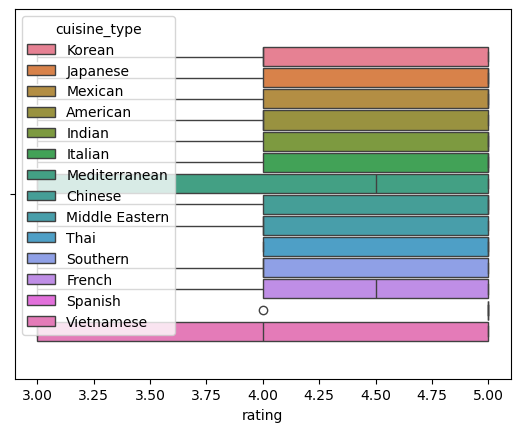

In [49]:
sns.boxplot(df_foodhub_orders, x='rating', hue='cuisine_type', gap=0.1);

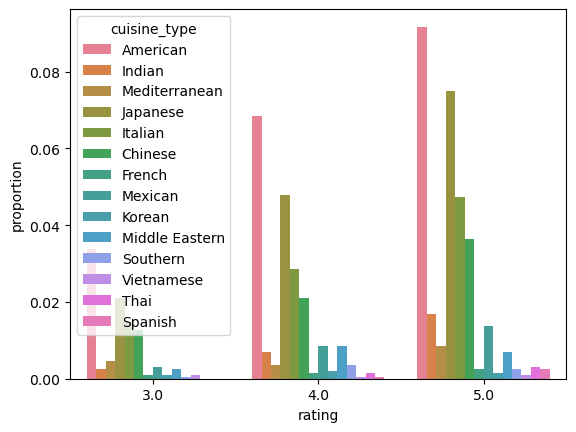

In [50]:
sns.countplot(df_foodhub_orders, x='rating', hue='cuisine_type', stat='proportion');

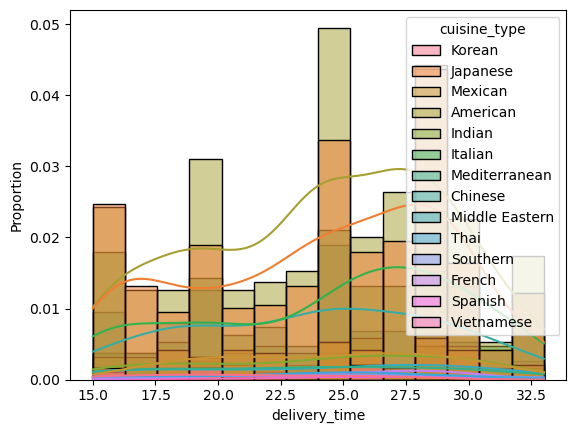

In [51]:
sns.histplot(df_foodhub_orders, x='delivery_time', hue='cuisine_type', stat='proportion', kde=True);

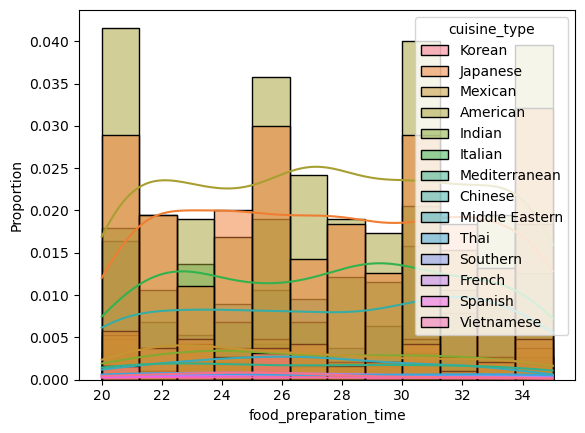

In [52]:
sns.histplot(df_foodhub_orders, x='food_preparation_time', hue='cuisine_type', stat='proportion', kde=True);

#### Observations
* Rating count increases with increasing rating (3 to 4 to 5) for each cusine type
* Delivery time and food preparatin time looks to be similar for all cuisine types without major differences.
* Vietnamese seems to be lowly rated relative to other cuisines.

In [53]:
numeric_channels_list = df_foodhub_orders.select_dtypes(include='number').columns.tolist()
numeric_channels_list

['order_id',
 'customer_id',
 'cost_of_the_order',
 'rating',
 'food_preparation_time',
 'delivery_time']

In [54]:
df_corr = df_foodhub_orders[['cost_of_the_order', 'rating',  'food_preparation_time', 'delivery_time']].corr()
df_corr

,cost_of_the_order,rating,food_preparation_time,delivery_time
cost_of_the_order,1.000000,0.033983,0.041527,-0.029949
rating,0.033983,1.000000,-0.006083,-0.009804
food_preparation_time,0.041527,-0.006083,1.000000,0.011094
delivery_time,-0.029949,-0.009804,0.011094,1.000000


<Axes: >

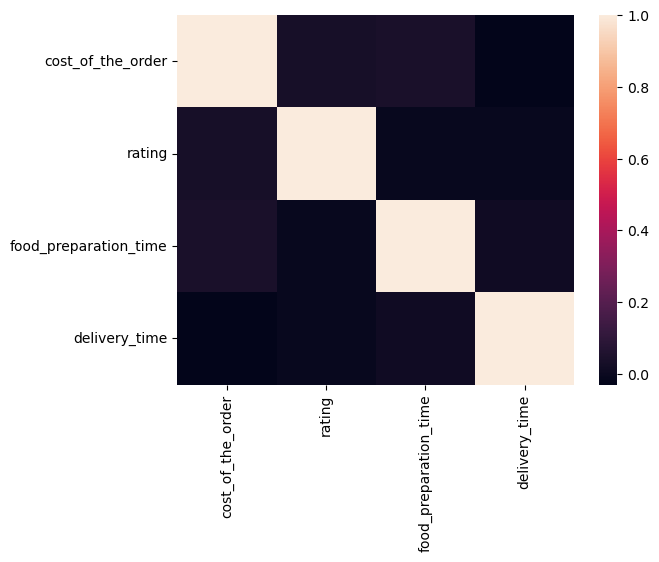

In [55]:
sns.heatmap(df_corr)

#### Observations
* The numerical columns are not correlated or have close to zero correlation.
* Categorical column as day of the week shows some trends in delivery time and rating of the restaurant.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [56]:
# Write the code here
number_of_ratings_by_restaurant = df_foodhub_orders.groupby(by="restaurant_name")['rating'].count()
number_of_ratings_by_restaurant

restaurant_name
'wichcraft           1
12 Chairs            2
5 Napkin Burger      2
67 Burger            1
Alidoro              0
                    ..
Zero Otto Nove       1
brgr                 1
da Umberto           1
ilili Restaurant    13
indikitch            2
Name: rating, Length: 178, dtype: int64

In [57]:
number_of_ratings_by_restaurant.sort_values(ascending=False)

restaurant_name
Shake Shack                     133
The Meatball Shop                84
Blue Ribbon Sushi                73
Blue Ribbon Fried Chicken        64
RedFarm Broadway                 41
                               ... 
Rohm Thai                         0
Spice Thai                        0
Posto                             0
Tarallucci e Vino Restaurant      0
Wa Jeal                           0
Name: rating, Length: 178, dtype: int64

In [58]:
min_50_ratings_restaurants = number_of_ratings_by_restaurant[number_of_ratings_by_restaurant>50.0]
min_50_ratings_restaurants

restaurant_name
Blue Ribbon Fried Chicken     64
Blue Ribbon Sushi             73
Shake Shack                  133
The Meatball Shop             84
Name: rating, dtype: int64

In [59]:
list_of_restaurants_more_than_50_reviews = list(min_50_ratings_restaurants.index)
list_of_restaurants_more_than_50_reviews

['Blue Ribbon Fried Chicken',
 'Blue Ribbon Sushi',
 'Shake Shack',
 'The Meatball Shop']

In [60]:
mean_of_ratings_by_restaurant = df_foodhub_orders.groupby(by="restaurant_name")['rating'].mean()
mean_of_ratings_by_restaurant

restaurant_name
'wichcraft          5.000000
12 Chairs           4.500000
5 Napkin Burger     4.000000
67 Burger           5.000000
Alidoro                  NaN
                      ...   
Zero Otto Nove      4.000000
brgr                3.000000
da Umberto          5.000000
ilili Restaurant    4.153846
indikitch           4.500000
Name: rating, Length: 178, dtype: float64

In [61]:
mean_of_ratings_by_restaurant_greater_than_4 = mean_of_ratings_by_restaurant[mean_of_ratings_by_restaurant>4.0]
mean_of_ratings_by_restaurant_greater_than_4

restaurant_name
'wichcraft                  5.000000
12 Chairs                   4.500000
67 Burger                   5.000000
Amma                        4.500000
Anjappar Chettinad          5.000000
                              ...   
Yama 49                     5.000000
Yama Japanese Restaurant    4.500000
da Umberto                  5.000000
ilili Restaurant            4.153846
indikitch                   4.500000
Name: rating, Length: 110, dtype: float64

In [62]:
mean_of_ratings_by_restaurant_greater_than_4[list_of_restaurants_more_than_50_reviews]

restaurant_name
Blue Ribbon Fried Chicken    4.328125
Blue Ribbon Sushi            4.219178
Shake Shack                  4.278195
The Meatball Shop            4.511905
Name: rating, dtype: float64

In [63]:
list(mean_of_ratings_by_restaurant_greater_than_4[list_of_restaurants_more_than_50_reviews].index)

['Blue Ribbon Fried Chicken',
 'Blue Ribbon Sushi',
 'Shake Shack',
 'The Meatball Shop']

#### Observations:
There are 4 restaurants with at least 50 reviews and greater than 4.0 average rating. The list of restaurants with at least 50 reviews and greater 4.0 average ratings are below:

1. 'Blue Ribbon Fried Chicken',
2. 'Blue Ribbon Sushi',
3. 'Shake Shack',
4. 'The Meatball Shop'


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [64]:
# Write the code here
def foodhub_surcharge(value):
    if value>20.0:
        return value*1.25 # Applying 25% surcharge
    elif (value>5.0) & (value<=20.0):
        return value*1.15 # Applying 15% surcharge
    else:
        return value

In [65]:
df_foodhub_orders['cost_of_the_order_w_surcharge'] = df_foodhub_orders['cost_of_the_order'].apply(foodhub_surcharge)

In [66]:
# checking if the everything was implemented correctly
df_foodhub_orders[['cost_of_the_order', 'cost_of_the_order_w_surcharge']].sample(20)

,cost_of_the_order,cost_of_the_order_w_surcharge
1800,24.30,30.3750
1888,16.20,18.6300
245,13.00,14.9500
31,29.05,36.3125
76,29.29,36.6125
59,6.79,7.8085
6,6.07,6.9805
123,12.32,14.1680
58,14.02,16.1230
867,11.64,13.3860


In [67]:
print(f'Revenue of the company ${df_foodhub_orders.cost_of_the_order_w_surcharge.sum()} \n Cost per order is: ${df_foodhub_orders.cost_of_the_order_w_surcharge.sum()/len(df_foodhub_orders)}')

Revenue of the company $37481.123 
 Cost per order is: $19.747693888303477


#### Observations:
* The total revenue is sum of the column where cost of the order with surcharges is determined.
* The total revenue comes out to 37,481.12 dollars
* Revenue per order is 19.75 dollars

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [68]:
# Generate total_time_to_deliver
df_foodhub_orders['total_time_to_deliver'] = df_foodhub_orders['food_preparation_time']+df_foodhub_orders['delivery_time']
df_foodhub_orders['total_time_to_deliver'] 

0       45
1       48
2       51
3       40
4       49
        ..
1893    48
1894    50
1895    55
1896    54
1897    52
Name: total_time_to_deliver, Length: 1898, dtype: int64

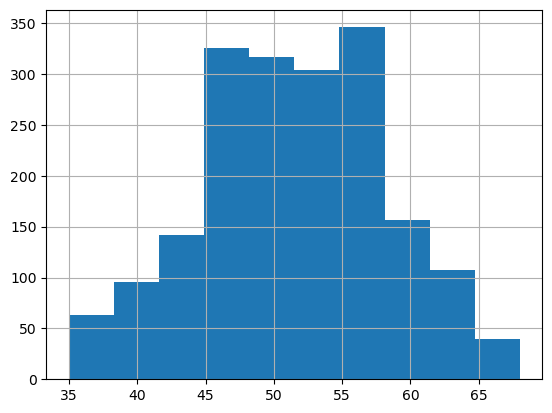

In [69]:
df_foodhub_orders['total_time_to_deliver'].hist();

In [70]:
# Write the code here
100*len(df_foodhub_orders[df_foodhub_orders['total_time_to_deliver']>60.0])/len(df_foodhub_orders)

10.53740779768177

#### Observations:
* Created a new column in minutes which adds up food_preparation_time and delivery_time to get the total time to deliver food
* We see that 10.54 %  of orders have a total delivery time of greater than 60 minutes.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

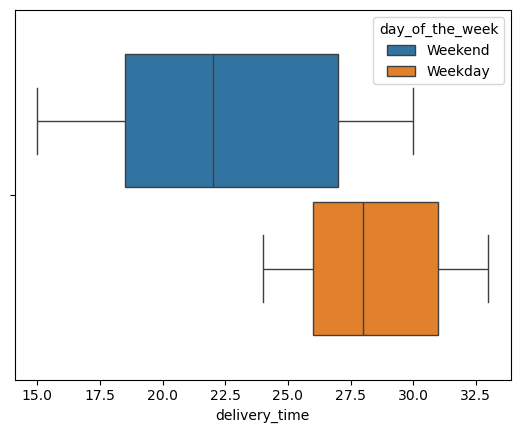

In [71]:
sns.boxplot(df_foodhub_orders, x='delivery_time', hue='day_of_the_week', gap=0.1);

In [72]:
# Write the code here
df_foodhub_orders.groupby(by=['day_of_the_week'])['delivery_time'].mean()

day_of_the_week
Weekday    28.340037
Weekend    22.470022
Name: delivery_time, dtype: float64

In [73]:
df_foodhub_orders.groupby(by=['day_of_the_week'])['delivery_time'].mean().iloc[0]

np.float64(28.340036563071298)

In [74]:
100*(df_foodhub_orders.groupby(by=['day_of_the_week'])['delivery_time'].mean().iloc[0]/df_foodhub_orders.groupby(by=['day_of_the_week'])['delivery_time'].mean().iloc[1])

np.float64(126.12375859508293)

#### Observations:
* Weekday delivery time is 28.34 minutes compared to Weekend delivery time of 22.47 minutes
* Weekday delivery time is around 26.12% greater than Weekend delivery time
* Cause of this must be looked into, it might order time is close to rush hour traffic or post-office dinner pickup maybe? A future direction for data collection.

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
* The total revenue comes out to 37,481.12 dollars, and the revenue per order is 19.75 dollars
*  71% of the orders are placed on the weekend, with delivery time being much faster relative to weekdays and ratings have skew towards the higher side for weekend orders too.
*  Top 5 cuisines account for 86.62% of the orders and them being American, Japanese, Italian, Chinese, and Mexican.
*  4 restaurants have at least 50 orders and rating higher than 4. These are: Blue Ribbon Fried Chicken, Blue Ribbon Sushi, Shake Shack, and The Meatball Shop. Foodhub should look into why these restaurants are popular and highly rated. This knowledge can be used to bring other restaurants close to these in orders and ratings to reach the same level as these.

  

### Recommendations:

*  Food Preparation time is similar across different cuisine types. To improve time taken to deliver food from time of order, main focus should be put on improving delivery times of the orders.
*  Tor 5 cuisines account for 86.62% of the orders, either focus on these top 5 or we can improve marketing of cuisines outside the top 5 cuisines by targeted marketing campaigns.
*  Weekdays account for only 29% of the orders eventhough they are 5/7 days of the week.
*  Combining the above information, targeted marketing campaigns based on time of day for weekdays (avoiding rush hour traffic), addressing top 5 or outside of top 5 cuisines, and improving order traffic on weekdays look to be areas of growth for orders via foodhub.
*  For data collection, we can add tags of rush hour and non-rush hour tags to understand why delivery times discrepancy exists between weekdays and weekends.
*  We have the distrubutions of orders by customer id, these can be used to encourage discounts to customers to order more or create a marketing campaign where the top 5 customers receive prizes to encourage more consumer spending.

---